# **Práctica de Laboratorio Nro. 004: Variables Aleatorias Discretas y Continuas**

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Realizado por:** Freddy Ordoñez  
###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 02 de mayo de 2026

---

## 1. Introducción
En esta práctica se explora la naturaleza del azar mediante la modelación computacional. Utilizaremos el ecosistema de ciencia de datos de Python para diferenciar empíricamente entre variables discretas (lanzamiento de dados) y continuas (tiempos de respuesta de servidores).

## 2. Objetivos de Aprendizaje
* Diferenciar entre variables aleatorias discretas y continuas.
* Interpretar y construir funciones de masa de probabilidad (PMF) y funciones de densidad (PDF).
* Calcular probabilidades acumuladas usando la función de distribución acumulada (CDF).

## **Tarea 1: Configuracion del Entorno**
1.	Abra Jupyter Notebook o Google Colab.
2.	Importe las librerias necesarias:



In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, norm, binom, uniform
import seaborn as sns

# Configuracion de estilo
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Entorno configurado correctamente")


Entorno configurado correctamente


## **Tarea 2: Variable Aleatoria Discreta - Lanzamiento de Dado**
**Caso:** X = resultado del lanzamiento de un dado justo.
2.	Defina la variable aleatoria y su PMF:


In [23]:
# Variable aleatoria: resultado de un dado
# X puede tomar valores: 1, 2, 3, 4, 5, 6

# Valores posibles
x_valores = np.array([1, 2, 3, 4, 5, 6])

# PMF: cada valor tiene probabilidad 1/6
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

print("Valores de X:", x_valores)
print("PMF p(x):", pmf_dado)
print("Suma de probabilidades:", np.sum(pmf_dado))


Valores de X: [1 2 3 4 5 6]
PMF p(x): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Suma de probabilidades: 0.9999999999999999


3.	Visualice la PMF:

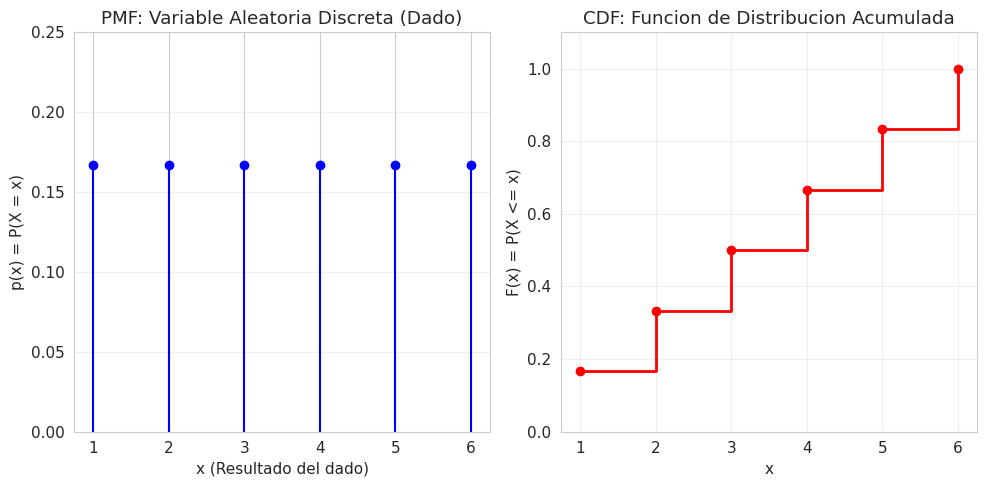

In [24]:
# Visualizacion de la PMF
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')
plt.xticks(x_valores)
plt.ylim(0, 0.25)
plt.grid(axis='y', alpha=0.3)

# CDF
cdf_dado = np.cumsum(pmf_dado)
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2)
plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Funcion de Distribucion Acumulada')
plt.xticks(x_valores)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



4.	Calcule probabilidades especificas:

In [25]:
# a) P(X = 4)
prob_4 = pmf_dado[x_valores == 4][0]
print(f"P(X = 4) = {prob_4:.4f}")

# b) P(X <= 3) usando CDF
prob_menor_3 = cdf_dado[x_valores == 3][0]
print(f"P(X <= 3) = {prob_menor_3:.4f}")

# c) P(2 <= X <= 5)
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]
print(f"P(2 <= X <= 5) = {prob_entre_2_5:.4f}")


P(X = 4) = 0.1667
P(X <= 3) = 0.5000
P(2 <= X <= 5) = 0.6667


## **Tarea 3: Variable Aleatoria Continua - Distribucion Normal**
**Caso:** X = tiempo de respuesta de un servidor (ms), distribuido normalmente con mu = 200 y sigma = 30.

1.	Defina la distribucion y visualice la PDF:


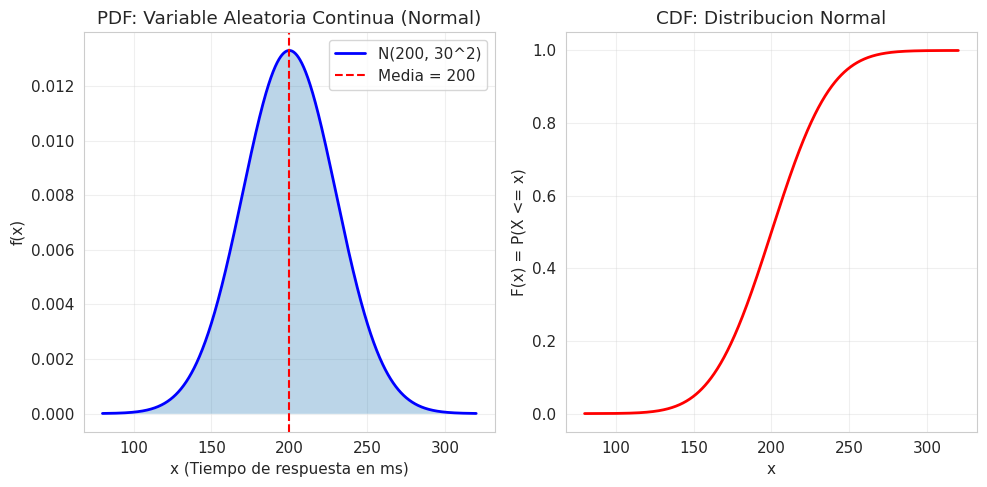

In [26]:
# Parametros de la distribucion normal
mu = 200  # media
sigma = 30  # desviacion estandar

# Crear la distribucion
dist_normal = norm(loc=mu, scale=sigma)

# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# PDF
pdf_normal = dist_normal.pdf(x)

# Visualizacion
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, pdf_normal, 'b-', linewidth=2, label=f'N({mu}, {sigma}^2)')
plt.fill_between(x, pdf_normal, alpha=0.3)
plt.axvline(mu, color='red', linestyle='--', label=f'Media = {mu}')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('f(x)')
plt.title('PDF: Variable Aleatoria Continua (Normal)')
plt.legend()
plt.grid(alpha=0.3)

# CDF
cdf_normal = dist_normal.cdf(x)
plt.subplot(1, 2, 2)
plt.plot(x, cdf_normal, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Distribucion Normal')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


2.	Calcule probabilidades:

In [27]:
# a) P(X <= 180)
prob_menor_180 = dist_normal.cdf(180)
print(f"P(X <= 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")

# b) P(X > 250)
prob_mayor_250 = 1 - dist_normal.cdf(250)
print(f"P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")

# c) P(170 <= X <= 230)
prob_entre = dist_normal.cdf(230) - dist_normal.cdf(170)
print(f"P(170 <= X <= 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")

# d) Percentil 95
p95 = dist_normal.ppf(0.95)
print(f"\nPercentil 95: {p95:.2f} ms")
print(f"El 95% de los tiempos de respuesta son menores a {p95:.2f} ms")


P(X <= 180) = 0.2525 (25.25%)
P(X > 250) = 0.0478 (4.78%)
P(170 <= X <= 230) = 0.6827 (68.27%)

Percentil 95: 249.35 ms
El 95% de los tiempos de respuesta son menores a 249.35 ms


## **Tarea 4: Comparacion Visual PMF vs PDF**

1.	Cree una visualizacion comparativa:


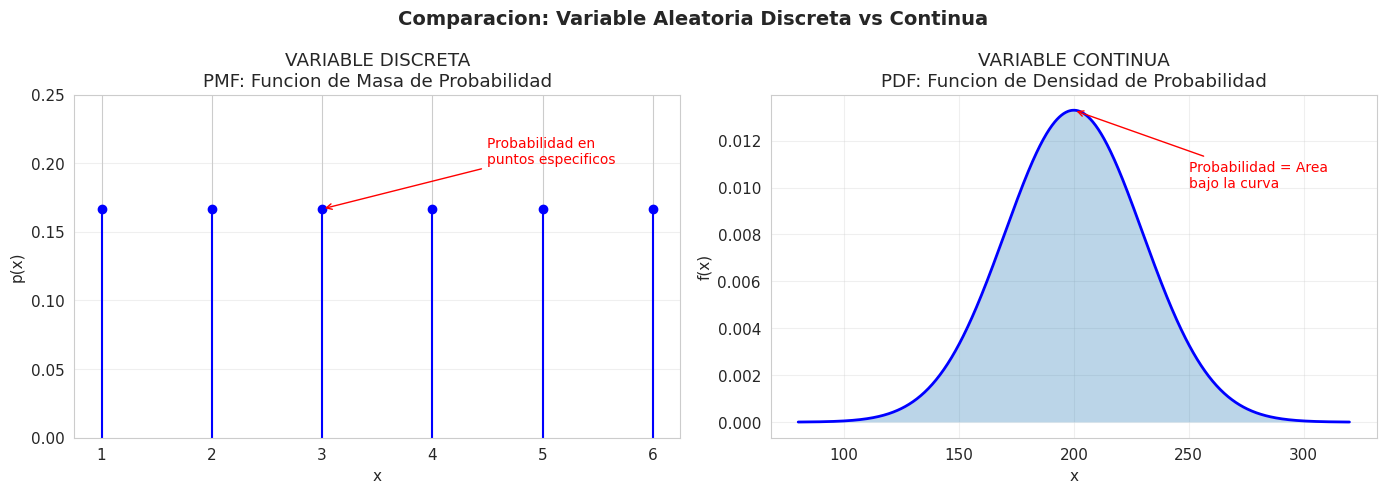

In [28]:
# Comparacion PMF vs PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variable Discreta (Dado)
axes[0].stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Funcion de Masa de Probabilidad')
axes[0].set_xticks(x_valores)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)

# Anotaciones
axes[0].annotate('Probabilidad en\npuntos especificos', xy=(3, 1/6), xytext=(4.5, 0.2),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

# Variable Continua (Normal)
axes[1].plot(x, pdf_normal, 'b-', linewidth=2)
axes[1].fill_between(x, pdf_normal, alpha=0.3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Funcion de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)

# Anotaciones
axes[1].annotate('Probabilidad = Area\nbajo la curva', xy=(200, norm.pdf(200, 200, 30)), xytext=(250, 0.01),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

plt.suptitle('Comparacion: Variable Aleatoria Discreta vs Continua', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## **Tarea 5: Aplicacion - Variables Aleatorias en la UNL**

***1.	En su grupo, identifique 5 variables aleatorias en diferentes areas de la UNL:***

•	Biblioteca: _________________________________________________

•	Cafeteria: _________________________________________________

•	Laboratorios: ______________________________________________

•	Estacionamiento: ___________________________________________

•	Aulas de clase: ____________________________________________

***2.	Para cada variable, determine:***

•	Tipo: Discreta / Continua

•	Posibles valores que puede tomar

•	Distribucion de probabilidad esperada (si se puede inferir)

***10.	Complete la tabla de registro:***


In [29]:
import pandas as pd

# 1. Configuración para separar y organizar las columnas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
# Removed pd.set_option('display.unicode.east_asian_width', True) as it can cause misalignment

# 2. Plantilla con encabezados en MAYÚSCULAS
variables_unl = [
    {
        'NOMBRE': 'Libros prestados por día',
        'UBICACION': 'Biblioteca Central',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0, 1, 2, ..., 200',
        'DISTRIBUCION ESPERADA': 'Poisson'
    },
    {
        'NOMBRE': 'Gasto promedio por estudiante',
        'UBICACION': 'Cafetería Central',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '$0.50 a $15.00',
        'DISTRIBUCION ESPERADA': 'Normal'
    },
    {
        'NOMBRE': 'Uso de maquinas por hora',
        'UBICACION': 'Lab. Computación',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0 a 10 maquinas',
        'DISTRIBUCION ESPERADA': 'Geométrica'
    },
    {
        'NOMBRE': 'Ocupación de estacionamiento (%)',
        'UBICACION': 'Estacionamiento UNL',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '0% a 100%',
        'DISTRIBUCION ESPERADA': 'Uniforme'
    },
    {
        'NOMBRE': 'Calificación final en Estadística',
        'UBICACION': 'Aulas de clase',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '0 a 10',
        'DISTRIBUCION ESPERADA': 'Beta'
    }
]

df = pd.DataFrame(variables_unl)

# 3. Use display(df) for a much better visual presentation in Colab
display(df)

,NOMBRE,UBICACION,TIPO,VALORES POSIBLES,DISTRIBUCION ESPERADA
0,Libros prestados por día,Biblioteca Central,Discreta,"0, 1, 2, ..., 200",Poisson
1,Gasto promedio por estudiante,Cafetería Central,Continua,$0.50 a $15.00,Normal
2,Uso de maquinas por hora,Lab. Computación,Discreta,0 a 10 maquinas,Geométrica
3,Ocupación de estacionamiento (%),Estacionamiento UNL,Continua,0% a 100%,Uniforme
4,Calificación final en Estadística,Aulas de clase,Continua,0 a 10,Beta


#**TRABAJO AUTONOMO**

1.	Modifique el codigo de la Tarea 3 para representar una variable de su eleccion:

* Opcion A: Distribución Bernoulli (lanzamiento de moneda)

* Opcion B: Distribución Uniforme discreta

* Opcion C: Distribución Binomial

* Genere las gráficas PMF/PDF y CDF para su distribución seleccionada.

* Calcule al menos 3 probabilidades especificas e interprete los resultados


* Entregue un archivo. ipynb con:**

* Código funcional y comentado

* Visualizaciones claras

* Interpretación de resultados



---

## 👤 Freddy Ordoñez  

---

### 1. Selección de la Distribución
*   **Distribución Elegida:** Distribución Binomial (Opción C).

### 2. Justificación Técnica
He seleccionado la Distribución Binomial debido a su relevancia crítica en la ingeniería en computación, ya que permite modelar procesos independientes con resultados binarios de éxito o fracaso, como la tasa de transmisión de paquetes en una red, la detección de errores en cadenas de bits o la disponibilidad de servidores en un clúster. A diferencia de otros modelos, la Binomial facilita la predicción precisa de obtener un número específico de éxitos ($k$) en un total de intentos ($n$) basándose en una probabilidad fija ($p$), lo que resulta fundamental para optimizar sistemas tecnológicos y tomar decisiones informadas bajo condiciones de incertidumbre en entornos reales como los laboratorios de la UNL.

---

### 3. Implementación y Resultados Esperados


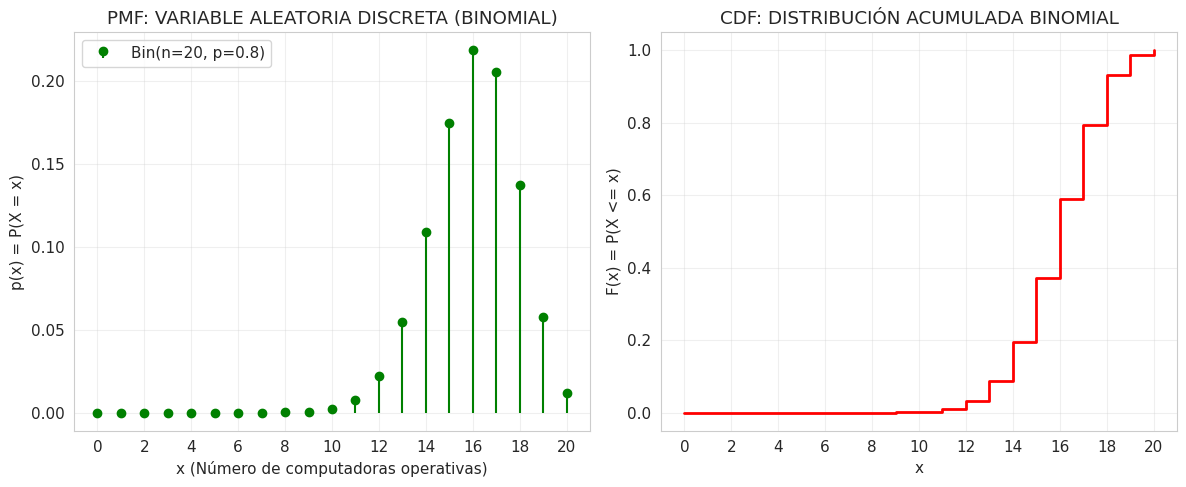

       ANÁLISIS DE PROBABILIDADES BINOMIAL        
--------------------------------------------------
a) P(X = 16) = 0.2182 (21.82%)
Interpretación: Probabilidad de encontrar exactamente 16 equipos operativos.

b) P(X <= 12) = 0.0321 (3.21%)
Interpretación: Existe un riesgo muy bajo (3.21%) de tener 12 o menos PCs funcionales.

c) P(15 <= X <= 18) = 0.7350 (73.50%)
Interpretación: Es el escenario más probable para el mantenimiento del laboratorio.

Percentil 95: 19
Interpretación: El 95% de las veces, habrá al menos 19 equipos funcionando o menos.


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# PARÁMETROS DE LA DISTRIBUCIÓN BINOMIAL (Fase 3 - Opción C)
# Ejemplo: Estado de 20 computadoras en el laboratorio de la UNL
n = 20    # Número de ensayos (computadoras totales)
p = 0.8   # Probabilidad de éxito (probabilidad de que una PC funcione correctamente)

# Crear la distribución
dist_binomial = binom(n, p)

# Rango de valores para graficar (de 0 a n éxitos)
x = np.arange(0, n + 1)

# PMF: Función de Masa de Probabilidad
pmf_binomial = dist_binomial.pmf(x)

# VISUALIZACIÓN
plt.figure(figsize=(12, 5))

# Gráfica de la PMF
plt.subplot(1, 2, 1)
plt.stem(x, pmf_binomial, linefmt='g-', markerfmt='go', basefmt=" ", label=f'Bin(n={n}, p={p})')
plt.xlabel('x (Número de computadoras operativas)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: VARIABLE ALEATORIA DISCRETA (BINOMIAL)')
plt.legend()
plt.xticks(np.arange(0, n + 1, 2))
plt.grid(alpha=0.3)

# Gráfica de la CDF
cdf_binomial = dist_binomial.cdf(x)
plt.subplot(1, 2, 2)
plt.step(x, cdf_binomial, 'r-', linewidth=2, where='post')
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: DISTRIBUCIÓN ACUMULADA BINOMIAL')
plt.xticks(np.arange(0, n + 1, 2))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ANÁLISIS DE RESULTADOS E INTERPRETACIÓN
print(f"{'ANÁLISIS DE PROBABILIDADES BINOMIAL':^50}")
print("-" * 50)

# a) P(X = 16) - Probabilidad de que exactamente 16 computadoras funcionen
prob_exacta = dist_binomial.pmf(16)
print(f"a) P(X = 16) = {prob_exacta:.4f} ({prob_exacta*100:.2f}%)")
print("Interpretación: Probabilidad de encontrar exactamente 16 equipos operativos.")

# b) P(X <= 12) - Probabilidad de que 12 o menos computadoras funcionen
prob_menor_12 = dist_binomial.cdf(12)
print(f"\nb) P(X <= 12) = {prob_menor_12:.4f} ({prob_menor_12*100:.2f}%)")
print(f"Interpretación: Existe un riesgo muy bajo ({prob_menor_12*100:.2f}%) de tener 12 o menos PCs funcionales.")

# c) P(15 <= X <= 18) - Probabilidad de un rango operativo común
# Calculado como P(X <= 18) - P(X <= 14)
prob_rango = dist_binomial.cdf(18) - dist_binomial.cdf(14)
print(f"\nc) P(15 <= X <= 18) = {prob_rango:.4f} ({prob_rango*100:.2f}%)")
print("Interpretación: Es el escenario más probable para el mantenimiento del laboratorio.")

# d) Percentil 95
p95 = dist_binomial.ppf(0.95)
print(f"\nPercentil 95: {p95:.0f}")
print(f"Interpretación: El 95% de las veces, habrá al menos {p95:.0f} equipos funcionando o menos.")

---

#**Preguntas de Control**

---

### **1. ¿Cuál es la diferencia fundamental entre una variable aleatoria discreta y una continua?**

La diferencia principal radica en la **naturaleza del conjunto de valores** que la variable puede asumir y la metodología matemática para calcular sus probabilidades:

*   **Variable Aleatoria Discreta:** Es aquella que asume un número finito o infinito numerable de valores, generalmente números enteros. La probabilidad se asigna a puntos específicos mediante una **Función de Masa de Probabilidad (PMF)**, donde cada valor individual $x$ tiene una probabilidad propia es mayor o igual a cero.

*   **Variable Aleatoria Continua:** Es aquella que puede tomar cualquier valor dentro de un intervalo continuo de números reales. En este caso, no se asigna probabilidad a puntos exactos, sino a intervalos mediante el **área bajo la curva** de una **Función de Densidad de Probabilidad (PDF)**.

---

### **2. ¿Por qué en una variable continua $P(X = x) = 0$ para cualquier valor específico $x$?**
En las variables continuas, la probabilidad se define como el **área bajo la curva** dentro de un intervalo determinado. Debido a que este tipo de variables pueden tomar infinitos valores decimales, la probabilidad de que ocurra un valor con precisión exacta es matemáticamente nula.

Al intentar medir un solo punto, no existe un "ancho" o base para calcular dicha área, lo que resulta en una probabilidad de cero. Por esta razón, en ingeniería siempre se calcula la probabilidad de que un evento ocurra **dentro de un rango** y no en un instante o valor único.

---

### **3. Explique la relación entre la PMF/PDF y la CDF. ¿Cómo se obtiene una de la otra?**

La **PMF/PDF** describe la probabilidad en puntos o intervalos específicos, mientras que la **CDF** representa la probabilidad acumulada hasta un valor determinado. La relación entre ambas es de acumulación y cambio:

*   **Para obtener la CDF desde la PMF/PDF:** Se realiza un proceso de suma o integración. En variables discretas, la CDF se obtiene sumando las probabilidades individuales de la PMF hasta el punto deseado. En variables continuas, se obtiene calculando el área bajo la curva (integral) de la PDF desde el inicio hasta dicho punto.

*   **Para obtener la PMF/PDF desde la CDF:** Se realiza el proceso inverso. En el caso discreto, se restan los valores consecutivos de la CDF para encontrar la probabilidad de un punto. En el caso continuo, se calcula la derivada de la CDF para obtener la función de densidad original.
---

### **4. Una variable aleatoria $X$ representa el número de estudiantes que llegan tarde a clase. ¿Es $X$ discreta o continua? Justifique.**

La variable $X$ es **discreta**. Esto se debe a que el número de estudiantes se puede contar y pertenece a un conjunto de valores enteros finitos o infinitos numerables. No es posible tener fracciones de personas (como 2.5 estudiantes), lo cual es la característica principal de las variables discretas, a diferencia de las continuas que aceptan cualquier valor dentro de un intervalo real.

---

### **5. Calcule $P(X = 5)$ para una variable continua con PDF $f(x) = 2x$ en $[0,1]$. Explique su respuesta.**

La probabilidad $P(X = 5)$ es igual a **0**.

**Explicación:**
Primero, el valor $x = 5$ se encuentra fuera del rango definido para esta función ($[0, 1]$), por lo que su probabilidad es nula. Sin embargo, incluso si el valor estuviera dentro del rango, la probabilidad de cualquier punto exacto en una variable aleatoria continua es siempre **cero**. Esto se debe a que la probabilidad en distribuciones continuas se mide como el área bajo la curva en un intervalo; al ser un solo punto, no existe ancho ni área que calcular.

---

### **6. Dibuje aproximadamente la CDF de una variable discreta que toma valores {1, 2, 3} con probabilidades {0.3, 0.5, 0.2}.**
La gráfica resultante es **escalonada** (steps):
*   $F(x) = 0$ para $x < 1$
*   $F(x) = 0.3$ para $1 \le x < 2$
*   $F(x) = 0.8$ para $2 \le x < 3$
*   $F(x) = 1.0$ para $x \ge 3$

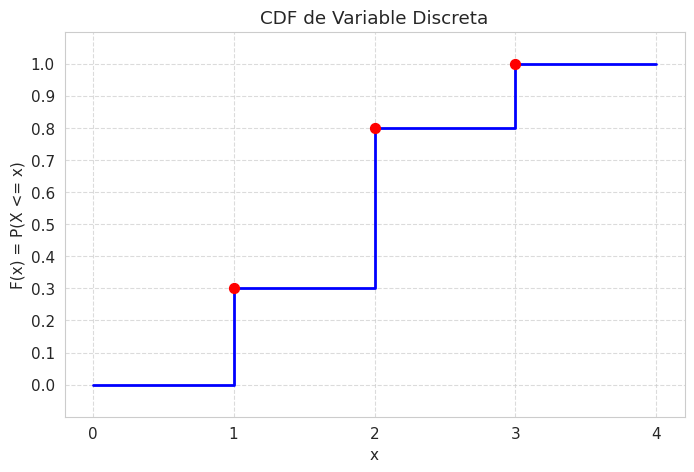

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de la variable discreta
x_values = np.array([1, 2, 3])
# Probabilidades
probabilities = np.array([0.3, 0.5, 0.2])

# Calcular la CDF
cdf_values = np.cumsum(probabilities)

# Preparar los puntos para la grafica escalonada
x_plot = np.array([0, 1, 2, 3, 4])
y_plot = np.array([0, cdf_values[0], cdf_values[1], cdf_values[2], cdf_values[2]])

plt.figure(figsize=(8, 5))
plt.step(x_plot, y_plot, where='post', color='blue', linewidth=2)

# Marcar los puntos de salto
plt.scatter(x_values, cdf_values, color='red', zorder=5, s=50)

# Etiquetas y titulo
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF de Variable Discreta')
plt.xticks(np.arange(min(x_values) - 1, max(x_values) + 2))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-0.1, 1.1)

plt.show()


---

### **7. Identifique una variable aleatoria continua en el contexto de la carrera de Computación y justifique porque es continua.**

**Ejemplo:** El tiempo de latencia de un paquete de datos en una red local (medido en milisegundos).

**Justificación:** Esta variable es **continua** porque el tiempo puede tomar cualquier valor dentro de un intervalo real. A diferencia de las variables discretas que se cuentan en números enteros, la latencia puede expresarse con una precisión infinita de decimales (por ejemplo, 15.428... ms), dependiendo únicamente de la capacidad de medición del instrumento o software utilizado.


---

## 📊 Conclusiones

* Se implementó con éxito la **Distribución Binomial** utilizando la librería `scipy.stats`, logrando modelar con precisión la probabilidad de éxito en sistemas tecnológicos, como la operatividad de equipos en los laboratorios de la **UNL**.

* Mediante las visualizaciones de la **PMF** y la **CDF**, se validó la naturaleza discreta de los datos, observando cómo la probabilidad se agrupa alrededor de la media según los parámetros de ensayos ($n$) y probabilidad de éxito ($p$) definidos.

* El análisis estadístico permitió concluir que modelos como la Binomial son herramientas fundamentales en la **Ingeniería en Computación** para predecir comportamientos en sistemas binarios y optimizar la toma de decisiones bajo incertidumbre.

## 💡 Recomendaciones

* Se sugiere experimentar con variaciones en el parámetro de probabilidad ($p$) para observar cómo se desplaza la campana de la distribución y cómo esto afecta la fiabilidad esperada de un sistema.
* Al trabajar con variables discretas en Python, es recomendable emplear estrictamente gráficos de tipo `stem` (para PMF) y `step` (para CDF), ya que representan correctamente los saltos finitos entre valores y evitan confusiones con distribuciones continuas.
* Para futuros proyectos de la asignatura, se propone aplicar estos modelos probabilísticos en la simulación de protocolos de red o en el análisis de fallos de hardware, integrando datos reales obtenidos en el campus de la **UNL**.

## 📚 9. Bibliografía

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, *Probabilidad y estadística para ingeniería y ciencias*, 9na ed. Ciudad de México, México: Cengage Learning, 2016.

[2] SciPy Community, "Statistical functions (scipy.stats)," SciPy Documentation.

[3] J. Hunter, D. Dale, E. Firing, y M. Droettboom, "Matplotlib: A 2D graphics environment," Computing in Science & Engineering, vol. 9, no. 3, pp. 90-95, 2007.
